<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/07_02_%EC%8B%AC%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D(%EB%94%A5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 딥러닝 : 인공 신경망에 층을 추가하여 데이터 셋을 분류한다. (심층 신경망)

# 실행할 때마다 동일한 결과를 얻기 위해, 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 최종적으로 만든다.
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras

(train_input, train_target), (
    test_input, test_target) = keras.datasets.fashion_mnist.load_data() # 케라스 API에서 패션 MNIST 데이터 셋을 불러온다. → 훈련 세트와 테스트 셋을 만든다.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
from sklearn.model_selection import train_test_split

# 이미지의 픽셀 값이 '0 ~ 155' 범위에서 '0 ~ 1' 범위로 변환된다.
train_scaled = train_input / 255.0
# 28 X 28 크기의 2차원 배열을 만들고 나서 784 크기의 1차원 배열로 펼친다.
train_scaled = train_scaled.reshape(-1, 28 * 28)

# 20%의 훈련 세트와 검증 세트로 분할한다.
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42
)

In [3]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [4]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [6]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [ ]:
# 인공 신경망 모델에 2개의 레이어를 추가해보자.
# 은닉층(Hidden Layer) : 입력층과 출력층 사이에 밀집층이 추가되었다. → 주황색 원으로 활성화 함수가 표시되어 있다.
# 활성화 함수 : 신경망 층의 선형 방정식 계산 값에 적용하는 함수 → 출력층에 적용되는 활성화 함수의 종류가 제한되어 있다. <=> 은닉층
# 분류를 위한 함수 : 시그모이드 함수 (이진 분류), 소프트맥스 함수 (다중 분류)

# 신경망 또한 마찬가지로, 은닉층에서 선형적인 산술 계산만 수행한다면 수행 역할이 없는 셈이다. → 선형 계산을 적당히 비선형적으로 비틀어 줘야 한다.

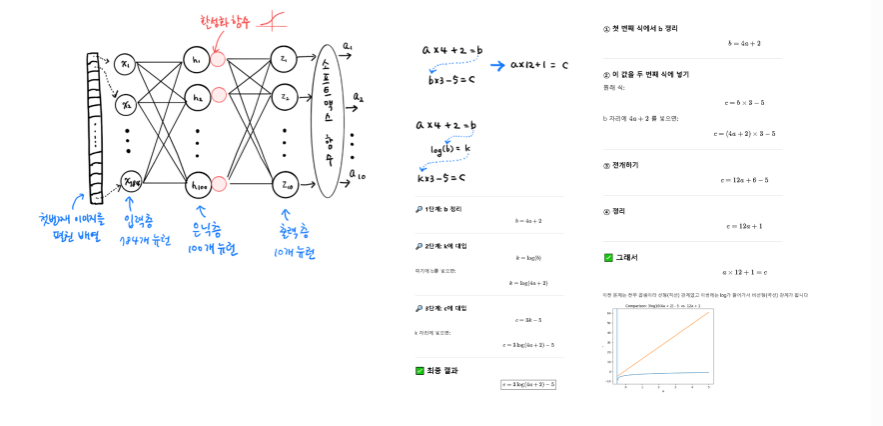

In [7]:
# 시그모이드 함수를 사용한 은닉층과 소프트맥스 함수를 사용한 출력층을 케라스 Dense 클래스로 생성해보자.
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)) # input_shape=(784,) : 입력의 크기 (필수) → 몇 개의 뉴런이 필요한지는 경험적으로 기입한다. (적어도 출력층의 뉴런보다는 많게 만들어야 한다.)
# dense1의 목표 : 784개의 입력을 시그모이드 함수를 통해 100개로 만든다.
# https://gooopy.tistory.com/52

dense2 = keras.layers.Dense(10, activation='softmax')
# https://wikidocs.net/120089

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 심층 신경망(순차적으로 적용하는 모델)을 만들어보자.
model = keras.Sequential([dense1, dense2])

# 위에서 만든 'dense1', 'dense2'를 'Sequential' 클래스에 추가함으로써 심층 신경망을 만든다. → 'dense1', 'dense2'를 리스트로 만들어 전달한다.
# 주의 사항 : '(은닉층, 출력층)' 순서에 맞춰 입력한다.
# 인공 신경망의 장점 : 2개 이상의 층을 추가할 수 있다. (연속적인 학습을 진행할 수 있다.)

In [10]:
model.summary() # 층에 대한 유용한 정보가 출력된다.

# 결과
# 첫 줄에 모델의 이름이 출력된다.
# Layer (type) : 해당 모델이 들어 있는 층이 순서대로 기재된다. → 층 이름을 지정하지 않으면 케라스가 자동으로 'Dense'라고 이름 붙인다.
# Output Shape (출력 크기) : (샘플의 개수, 은닉층의 뉴런 개수) → 미니 배치 경사 하강법
# 미니 배치 경사 하강법 : 케라스 모델의 'fit' 매서드에 훈련 데이터를 주입하면, 데이터를 한번에 다 사용하지 않고 잘게 나눈 후 여러 번에 걸쳐 경사 하강법의 단계를 수행한다. → 8의 배수 (32)
# Param (파라미터 개수) : 입력 개수 * 출력 개수 (절편) + 출력 개수 (절편) (e.g. 784 * 100 + 100 =  78,500)
# Non-trainable params : 훈련되지 않은 파라미터

#  배치 차원 : 신경망 층에서 입력되거나 출력되는 배열의 첫 번째 차원

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

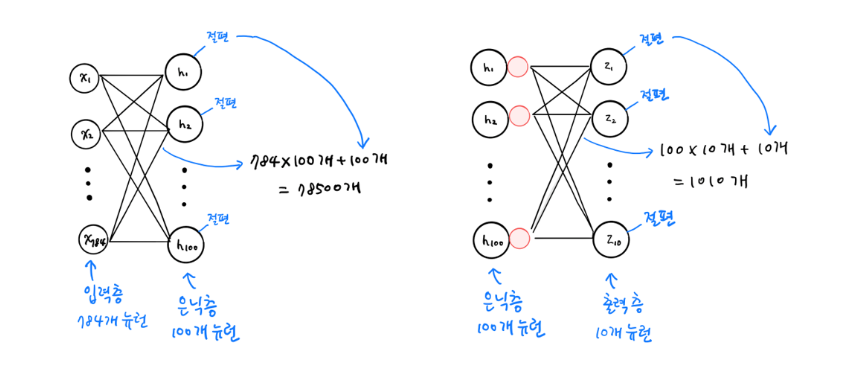

In [12]:
# 모델을 생성하면서 층을 추가하는 방법 → .add()
model = keras.Sequential()  # 새로운 모델을 생성한다.
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 모델을 훈련한다.
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_scaled, train_target, epochs=5)

# 결과 : 1개의 층으로 돌렸을 때보다 2개의 층으로 돌렸을 때 정확도가 더 높다. (약 85.37% → 약 87.40%)
# 주의 사항 : 0 밑으로 내려가면 무조건 0으로 처리한다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7525 - loss: 0.7720
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8463 - loss: 0.4270
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8604 - loss: 0.3857
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8696 - loss: 0.3600
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8759 - loss: 0.3410


In [15]:
model.evaluate(val_scaled, val_target)

# 결과 : 검증 점수 87.33%

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8733 - loss: 0.3530


[0.35684970021247864, 0.8694999814033508]

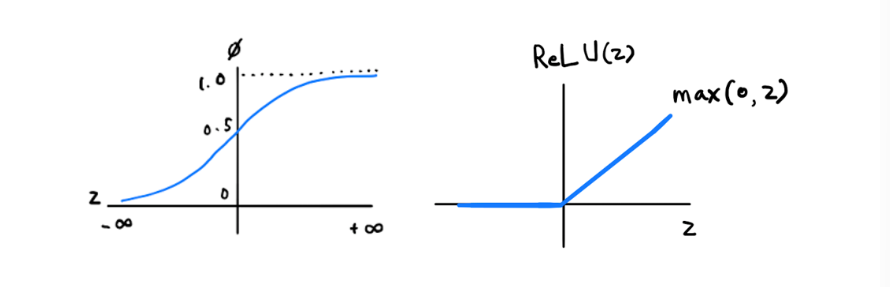

In [ ]:
# 시그모이드 함수는 인공 신경망의 은닉층에서 많이 활용되지만, 오른쪽 혹은 왼쪽 끝으로 갈수록 그래프가 눕기 때문에, 올바르게 출력하기가 어렵다는 단점이 존재한다.
# 시그모이드 함수의 단점을 개선하고자 제안된 함수가 렐루(ReLU) 함수이다.
# 렐루 함수 : 입력이 양수일 경우 활성화 함수가 없는 것처럼 통과시키고, 입력이 음수일 경우 0으로 만든다. → 이미지 처리에 효과적이다.
# 렐루 함수는 'max(0, z)'와 같이 사용되는데, z가 0보다 크면 z를 출력하고 0보다 작으면 0을 출력한다.

# 플래튼(Flatten) : 이미지 픽셀용으로서, 배치 차원을 제외한 나머지 입력 차원을 모두 일렬로 펼치는 역할만 수행한다. (e.g. '28 * 28 = 784'가 아닌 '28, 28'로 단조롭게 입력한다.) → 가중치와 절편이 없다.
# 절편 : x절편과 y절편을 통틀어 이르는 말
# 장점 : 플래튼 클래스에 포함된 피라미터가 0개이기 때문에, 케라스의 플래튼 층을 신경망 모델에 추가하면 입력 값의 차원을 짐작할 수 있다.

In [16]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28))) # 입력층 바로 뒤에 플래튼 층을 추가한다.

# (None, 784) → 784개의 입력이 첫 번째 은닉층에 전달되었음을 알 수 있다.
model.add(keras.layers.Dense(100, activation='relu')) # 렐루 층 : 'True or False'를 1단계에서 검사한다.
model.add(keras.layers.Dense(10, activation='softmax')) # 소프트맥스 층 : 다중 분류
model.summary() # 딥러닝 모델이 생성되었다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 훈련 데이터를 준비하여 모델을 훈련한다.
# 2차원 해상도의 값을 그대로 사용하기 위해 'reshape' 매서드를 제외한다.
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [21]:
print(train_scaled.shape, train_target.shape) # 플래튼을 사용하기 위해 픽셀 값은 조정하지 않는다.

(48000, 28, 28) (48000,)


In [22]:
print(val_scaled.shape, val_target.shape) # 플래튼을 사용하기 위해 픽셀 값은 조정하지 않는다.

(12000, 28, 28) (12000,)


In [23]:
# 순차적인 모델을 생성한 후, 컴파일을 통해 빠르게 처리한다.
model.compile(loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

# 훈련을 시작한다. (5번 반복)
model.fit(train_scaled, train_target, epochs=5)

# 결과 : 35초 정도 걸린다. → 시그모이드와 비교하면 향상되었다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7637 - loss: 0.6723
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8518 - loss: 0.4061
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8691 - loss: 0.3596
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8801 - loss: 0.3348
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8861 - loss: 0.3174


In [24]:
model.evaluate(val_scaled, val_target)

# 결과 : 검증 점수인 87.33%와 비교해보면 좋지 않다.

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8677 - loss: 0.3772


[0.37876638770103455, 0.8674166798591614]

In [ ]:
# 옵티마이저 : 최적화를 위해 하이퍼 파라미터를 자동으로 튜닝한다.

# 하이퍼 파라미터 : 모델이 자동으로 학습하지 않기 때문에 사용자가 직접 지정해야 하는 파라미터
# 1. 모델의 형태(구조)를 결정하는 하이퍼 파라미터
# 1) 은닉층의 개수 : 층을 얼마나 깊게 쌓을 것인가?
# 2) 뉴런의 개수 : 각 층에 지능(노드)을 얼마나 많이 배치할 것인가?
# 3) 활성화 함수 : 다음 층으로 신호를 보낼 때 어떤 기준(e.g. ReLU, Sigmoid)을 사용할 것인가?
# 4) 층의 종류 : 밀집층(Dense)을 사용할 것인가, 아니면 다른 층을 사용할 것인가?

# 2. 학습 방식(훈련)을 결정하는 하이퍼 파라미터
# 1) 배치 크기( batch_size) : 한 번에 몇 개의 데이터를 묶어서 공부할 것인가? (기본값 : 32)
# 2) 에포크(epochs) : 전체 데이터를 총 몇 번 반복해서 학습할 것인가?
# 3) 학습률(learning rate) : 가중치를 업데이트 할 때 얼마나 세밀하게 조정할 것인가?

# R(oot)M(ean)S(quare)prop(agation) : 케라스에서 'compile' 호출 시 별도 설정이 없으면 사용하는 옵티마이저 → 최근의 기울기 변화량을 고려하여 학습 속도를 적절하게 조절한다.
# S(tochastic) G(radient) D(escent) : 가장 고전적이고 기본이 되는 옵티마이저 → 원칙적으로 1개의 샘플만을 보며 내려가지만, 케라스는 효율을 위해 미니 배치 하강법을 사용한다.

In [25]:
sgd = keras.optimizers.SGD(learning_rate=0.1) # learning_rate 기본값 : 0.1

# 아래 그림처럼 다양한 최적화 기법이 존재한다.
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)
# 모멘텀 : 그레이디언트 가속도를 0.9 이상 사용한다.
# 네스테로프 모멘텀 : 모멘텀 최적화를 2번 반복하여 구현한다. → 기본적인 확률적 경사 하강법보다 더 나은 성능을 제공한다.

# 모델이 최적점에 가까이 갈수록 학습률을 낮출 수도 있다. → 적응적 학습률 (adaptive learning rate) : 안정적으로 최적점에 수렴한다.
# 적응적 학습률을 사용하는 대표적인 최적화 기법 : Adagrad, RMSprop

adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

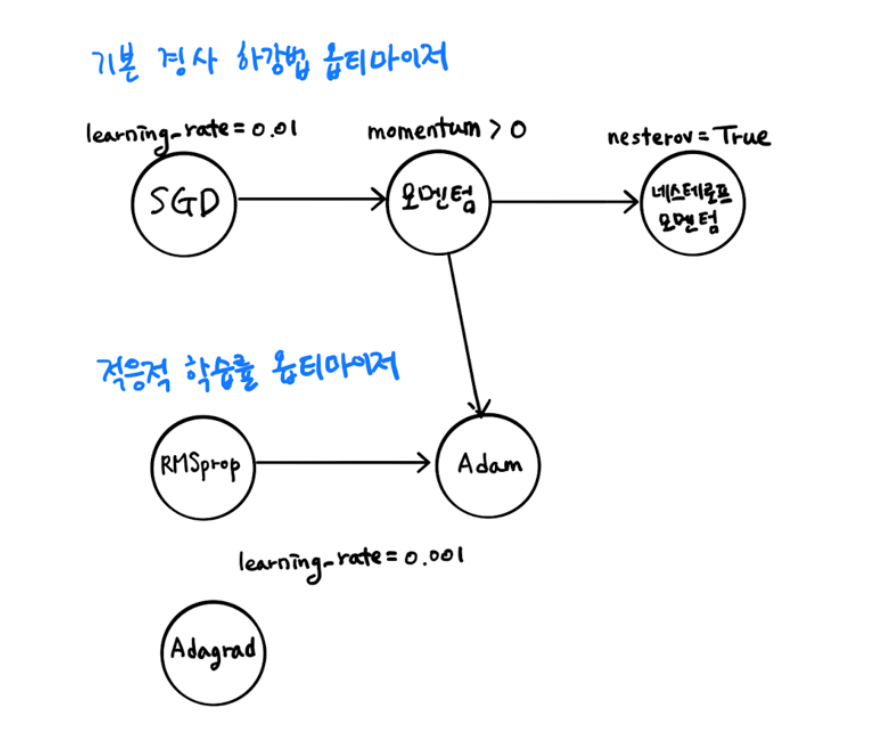

In [26]:
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
model = keras.Sequential() # 딥러닝의 레이어를 생성한다.
model.add(keras.layers.Flatten(input_shape=(28, 28))) # 입력층 (1차원으로 변환하지 않고 사용한다.)
model.add(keras.layers.Dense(100, activation='relu')) # 은닉층 : 렐루
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층 : 소프트맥스
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='adagrad', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # 적응적 학습률 최적화
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5269 - loss: 1.5234
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7469 - loss: 0.8030
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7818 - loss: 0.6957
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7973 - loss: 0.6437
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8045 - loss: 0.6110


In [30]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # 적응적 학습률 최적화
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8009 - loss: 0.5685
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8524 - loss: 0.4035
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8700 - loss: 0.3602
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8806 - loss: 0.3344
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8874 - loss: 0.3176


In [33]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# adam : 모멘텀 최적화와 RMSprop의 장점을 접목한 기법
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8889 - loss: 0.3040
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8982 - loss: 0.2807
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9032 - loss: 0.2652
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9060 - loss: 0.2546
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9116 - loss: 0.2401
